Running Base Case (No Filters)...

Running Standard Approach (Max Voltage Heuristic)...
Standard Filter Locations Selected: [29, 30, 31]

Running Proposed Iterative S-Parameter Algorithm...
Proposed Filter Locations Selected: [29, 10, 24]

Generating Performance Chart...


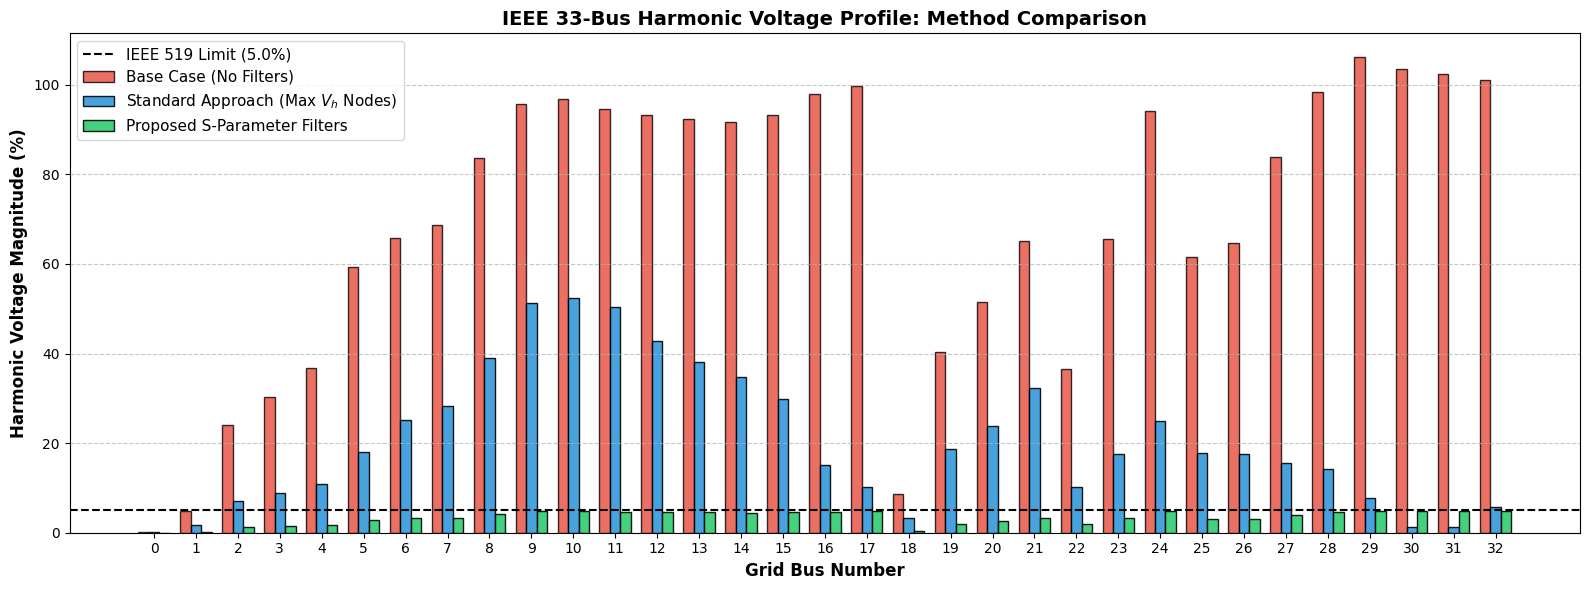


Chart generated and saved as 'Harmonic_Voltage_Profile_Comparison.png'


In [1]:
import numpy as np
import pandapower as pp
import pandapower.networks as nw
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP PANDAPOWER & PARAMETERS
# ==========================================
net = nw.case33bw()
N = len(net.bus)
K = 3            # Number of filters to place
h = 5            # Harmonic order
epsilon = 1e-6
harmonic_sources = [10, 24, 29] 
I_inj_mag = 1.0  

baseMVA = 10.0
Z_base = (net.bus.vn_kv.values**2) / baseMVA

def build_harmonic_ybus(net, placed_filters, h):
    Y = np.zeros((N, N), dtype=complex)
    for _, line in net.line.iterrows():
        fb, tb = int(line.from_bus), int(line.to_bus)
        r_pu = (line.r_ohm_per_km * line.length_km) / Z_base[fb]
        x_pu = (line.x_ohm_per_km * line.length_km) / Z_base[fb] * h 
        z_line = complex(r_pu, x_pu)
        y_line = 1.0 / z_line if abs(z_line) > 0 else 0
        
        Y[fb, tb] -= y_line
        Y[tb, fb] -= y_line
        Y[fb, fb] += y_line
        Y[tb, tb] += y_line
        
    for f_bus in placed_filters:
        Z_filter = complex(0.01, 0.05) 
        Y_filter = 1.0 / Z_filter
        Y[f_bus, f_bus] += Y_filter
    return Y

# ==========================================
# 2. HARMONIC PHYSICS ENGINE
# ==========================================
def run_pandapower_harmonic_solver(placed_filters):
    Y_h = build_harmonic_ybus(net, placed_filters, h)
    Y_h[0, 0] += complex(1000, -1000) # Slack bus connection
    
    Z_h = np.linalg.inv(Y_h)
    
    I_inj = np.zeros(N, dtype=complex)
    for src in harmonic_sources:
        I_inj[src] = complex(I_inj_mag, 0)
        
    V_h = Z_h @ I_inj
    Z_c = 1.0 
    a_current = (V_h + I_inj * Z_c) / 2.0
    b_current = (V_h - I_inj * Z_c) / 2.0
    
    T_current = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i != j and abs(a_current[i]) > epsilon:
                T_current[i, j] = abs(b_current[j]) / abs(a_current[i])
                
    if np.max(T_current) > 0:
        T_current = T_current / np.max(T_current)
        
    # Return the FULL voltage array (in percentage) for plotting
    v_h_array = np.abs(V_h) * 100 
    
    return a_current, b_current, T_current, v_h_array

# ==========================================
# 3. RUN ALGORITHMS (BASE, STANDARD, PROPOSED)
# ==========================================
print("Running Base Case (No Filters)...")
_, _, _, V_base_array = run_pandapower_harmonic_solver([])

print("\nRunning Standard Approach (Max Voltage Heuristic)...")
# Find the K buses with the highest voltage in the base case (excluding slack bus 0)
v_base_no_slack = V_base_array.copy()
v_base_no_slack[0] = 0.0 
# Get indices of the top K highest voltages
standard_filters = np.argsort(v_base_no_slack)[-K:][::-1].tolist()
_, _, _, V_standard_array = run_pandapower_harmonic_solver(standard_filters)
print(f"Standard Filter Locations Selected: {standard_filters}")

print("\nRunning Proposed Iterative S-Parameter Algorithm...")
proposed_filters = []
candidate_buses = list(range(1, N))

for k in range(K):
    a_curr, b_curr, T_curr, _ = run_pandapower_harmonic_solver(proposed_filters)
    influence = np.sum(T_curr, axis=1)
    
    scores = np.zeros(N)
    for i in candidate_buses:
        if abs(a_curr[i]) > epsilon:
            scores[i] = abs(a_curr[i]) * abs(b_curr[i]) * influence[i]
            
    best_node = candidate_buses[np.argmax(scores[candidate_buses])]
    proposed_filters.append(best_node)
    candidate_buses.remove(best_node)

_, _, _, V_proposed_array = run_pandapower_harmonic_solver(proposed_filters)
print(f"Proposed Filter Locations Selected: {proposed_filters}")

# ==========================================
# 4. PLOT THE 3-BAR COMPARISON CHART
# ==========================================
print("\nGenerating Performance Chart...")

fig, ax = plt.subplots(figsize=(16, 6)) # Slightly wider to accommodate 3 bars

x = np.arange(N)
width = 0.25  # Reduced width for 3 bars

# Create grouped bars
ax.bar(x - width, V_base_array, width, label='Base Case (No Filters)', color='#e74c3c', alpha=0.8, edgecolor='black')
ax.bar(x, V_standard_array, width, label='Standard Approach (Max $V_h$ Nodes)', color='#3498db', alpha=0.9, edgecolor='black')
ax.bar(x + width, V_proposed_array, width, label='Proposed S-Parameter Filters', color='#2ecc71', alpha=0.9, edgecolor='black')

# Add the IEEE 519 Standard Limit line
ieee_limit = 5.0
ax.axhline(y=ieee_limit, color='black', linestyle='--', linewidth=1.5, label=f'IEEE 519 Limit ({ieee_limit}%)')

# Formatting Labels and Titles
ax.set_xlabel('Grid Bus Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Harmonic Voltage Magnitude (%)', fontsize=12, fontweight='bold')
ax.set_title('IEEE 33-Bus Harmonic Voltage Profile: Method Comparison', fontsize=14, fontweight='bold')

# Format X-ticks
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x])

# Add grid lines
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add Legend
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('Harmonic_Voltage_Profile_Comparison.png', dpi=300)
plt.show()

print("\nChart generated and saved as 'Harmonic_Voltage_Profile_Comparison.png'")